# <u>Random Forest Regression</u>

### Prerequisites:
* <a href="../../1.Regression/7.Descision Trees Regression/Descision Trees Regression.ipynb">Check out the notebook on Decision Tree Regression</a>


## Topics

* [1. Core idea](#idea)
* [2. Bagging (Foundation of RF)](#bagging)
    * [**2.1 Regression**](#reg)
    * [2.2 Classification](#class)
        * <a href="../../2.Classification/7.Random Forest Classifier/Random Forest Classification.ipynb">Check out the notebook on Random Forest Classification</a>
* [3. What makes Random Forests different](#differ)
* [4. Performance Characteristics](#character)
* [5. Key Hyperparameters](#hyper)
* [6. Overfitting](#overfitting)
* [7. Out-of-Bag (OOB) Error](#oob)
* [8. Feature Importance](#important)
* [9. Proximities (Advanced Feature)](#proxi)
* [10. Advantages & Disadvantages](#adv_disadv)
* [11. Random Forest Regression library](#library)

    

In [250]:
import numpy as np # for rnadom number, linear algebra and general mathematical operations
import pandas as pd # for creating and working with dataframe
from matplotlib import pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go # for plotting in 3d
from sklearn.tree import DecisionTreeRegressor # for Regression trees
from sklearn.tree import plot_tree # for potting trees
from sklearn.tree import export_text # show tree rules
#from sklearn.preprocessing import OneHotEncoder # for one hot encoding of categoricals
#from sklearn.preprocessing import OrdinalEncoder # for ordinal labeling of categoricals with an order
from sklearn.impute import SimpleImputer # for replacing missing values
from sklearn.metrics import mean_squared_error # mean squarred error library
from sklearn.datasets import make_regression # to create toy data for regression
from sklearn.ensemble import RandomForestRegressor # for Random Forest Regressor
from sklearn.model_selection import train_test_split # for separating data set into train and test set
print("Setup complete")

Setup complete


<a class="anchor" id="idea"></a>
# 1. Core idea

- A Random Forest is an ensemble method that combines many decision trees
- It improves performance by:
    - Bagging (**Bootstrap Aggregation**) $\rightarrow$ training trees on different sampled datasets
    - Randomization $\rightarrow$ using random subsets of features at each split
- Works for both classification and regression

<p align="center">
<img src="pics/1.png" width="600"/>
</p>

---

<p align="center">
<img src="pics/2.png" width="600"/>
</p>

In [251]:
np.random.seed(1002) # reproducibility of random numbers
n = 100
X = np.random.uniform(0,10,(n,1))
y = np.sin(X.flatten()) + np.random.randn(n)*0.3


tree_model=DecisionTreeRegressor(max_depth=4,random_state=1008)
tree_model.fit(X,y)

fig = px.scatter(x=X.flatten(),y=y,title="Regression Tree Variability (poor performance)")
x_grid=np.linspace(np.min(X)-2,np.max(X)+2,100).reshape(-1,1)
pred_grid = tree_model.predict(x_grid)
fig.add_scatter(x=x_grid.flatten(), y=pred_grid, mode="lines", name="Original tree predictions")

for i in range(3):
    idx = np.random.choice(n,n,replace=True) # sample data with replacement
    X_changed = X[idx] # rearange data
    y_changed = y[idx] # reanrange data
    tree_model=DecisionTreeRegressor(max_depth=4,random_state=1008)
    tree_model.fit(X_changed,y_changed)
    pred_grid = tree_model.predict(x_grid)
    fig.add_scatter(x=x_grid.flatten(), y=pred_grid, mode="lines", name=f"Change data {i} time")


fig.show()

<a class="anchor" id="bagging"></a>
# 2. Bagging (Foundation of RF)

- Bagging means **B**ootstrap **Agg**regation
- Train multiple tree models (called Base learner) on bootstrap samples of training data $\mathcal{D}$ (sampling with replacement)
    - Draw $n$ observations from $\mathcal{D}$ with replacement
    - Fit Base learners/Tree models on each bootstrapped data $\mathcal{D}^{[m]}$ to obtain $m$ base learners $b^{[m]}$ 

<p align="center">
<img src="pics/7.png" width="600"/>
</p>

- Each model sees slightly different data:
    - In-bag data (IB): used for training 
    - Out-of-bag data (OOB): left out, used for validation


<p align="center">
<img src="pics/3.png" width="600"/>
</p>


#### Why Bagging it helps:
- Reduces variability of predictions by averaging the
outcomes from multiple Base learner models/ Tree models
- Works best for high-variance models like decision trees (in particular Classification trees)
- Increasing the ensemble size (number of Base learners) improves predictions stability even more (most for CLassification trees)


<p align="center">
<img src="pics/10.png" width="600"/>
</p>



<a class="anchor" id="reg"></a>
## **2.1 Regression**

<p align="center">
<img src="pics/8.png" width="600"/>
</p>

---

<p align="center">
<img src="pics/4.png" width="600"/>
</p>


In [252]:
np.random.seed(1838)
n = 100
x = np.random.uniform(0,10,n)
y = np.sin(x) + np.random.rand(n)*0.9


fig = px.scatter(x=x,y=y,title="Average Predictions of multiple Trees (Mini Random Forest without random feature sampling)")

tree_model=DecisionTreeRegressor(max_depth=4,random_state=1910)
tree_model.fit(x.reshape(n,1),y)
x_grid = np.linspace(np.min(x)-1,np.max(x)+1,100)
preds = tree_model.predict(x_grid.reshape(n,1))
fig.add_scatter(x=x_grid,y=preds,name="1. Tree Predictions")
num_trees = 3
predictions = preds.reshape(-1,1)
for i in range(2,num_trees+1):
    idx = np.random.choice(n,n,replace=True) # bootstrap sample
    x_bootstrap = x[idx]
    y_bootstrap = y[idx]
    tree_model.fit(x_bootstrap.reshape(n,1),y_bootstrap)
    preds = tree_model.predict(x_grid.reshape(n,1))
    fig.add_scatter(x=x_grid,y=preds,name=f"{i}. Tree Predictions")
    predictions = np.c_[predictions,preds]


fig.add_scatter(x=x_grid,y=np.mean(predictions,axis=1),name=f"Averaged Predictions",mode="lines",line=dict(width=5, dash="solid",color="black"))


fig.show()

In [253]:
np.random.seed(1838)
n = 100
x = np.random.uniform(0,10,n)
y = np.sin(x) + np.random.rand(n)*0.9


fig = px.scatter(x=x,y=y,title="Average Predictions of multiple Trees (still high variance due to correlated trees)")
num_trees = 4
x_grid = np.linspace(np.min(x)-1,np.max(x)+1,n*2)

for i in range(5): # get 5 averaged predictions
    all_preds = []
    for j in range(num_trees): # average over a few tree predictions
        idx = np.random.choice(n,n,replace=True)
        x_ = x[idx]
        y_ = y[idx]
        tree_model = DecisionTreeRegressor(max_depth=4)
        tree_model.fit(x_.reshape(-1,1),y_)
        pred = tree_model.predict(x_grid.reshape(-1,1))
        all_preds.append(pred.flatten())
    fig.add_scatter(x=x_grid,y=np.mean(all_preds,axis=0),name=f"{i}. Averaged Tree Predictions",mode="lines",line=dict(width=2))



fig.show()

In [254]:
n = 100
X,y = make_regression(n_samples=n,n_features=2,bias=4,coef=False,noise=50,random_state=1945)

tree_model=DecisionTreeRegressor(max_depth=4)
tree_model.fit(X,y)
x1_grid=np.linspace(np.min(X[:,0])-1,np.max(X[:,0])+1,100)
x2_grid=np.linspace(np.min(X[:,1])-1,np.max(X[:,1])+1,100)
xx,yy = np.meshgrid(x1_grid,x2_grid) # both xx and yy are of shape (n,n)
X_grid = np.column_stack((xx.flatten(),yy.flatten())) # xx.flatten() and yy.flatten() are of shape (n*n,)
preds = tree_model.predict(X_grid)

fig = px.scatter_3d(x=X[:,0],y=X[:,1],z=y,labels={"x":"x1","y":"x2","z":"x3"})
zz = preds.reshape(xx.shape) # zz is of shape (n,n)
fig.add_trace(go.Surface(x=xx,y=yy,z=zz,opacity=0.2,showscale=False,showlegend=True,name="1. Tree predictions",colorscale="blues"))

num_trees = 3
all_preds = []

for i in range(1,num_trees+1):
    idx = np.random.choice(n, n, replace=True)
    X_boot = X[idx]
    y_boot = y[idx]
    
    tree = DecisionTreeRegressor(max_depth=4)
    tree.fit(X_boot, y_boot)
    
    preds = tree.predict(X_grid)
    all_preds.append(preds)
    
    zz = preds.reshape(xx.shape)
    
    fig.add_trace(go.Surface(x=xx, y=yy, z=zz,opacity=0.2,showscale=False,name=f"{i+1}. Tree predictions",showlegend=True,colorscale="blues"))


avg_preds = np.mean(all_preds, axis=0)
zz_avg = avg_preds.reshape(xx.shape)

fig.add_trace(go.Surface(x=xx, y=yy, z=zz_avg,opacity=0.8,showscale=False,name="Average Predictions",colorscale="Viridis",showlegend=True))

fig.show()

<a class="anchor" id="class"></a>
## 2.2 Classification

<div style="display: flex; justify-content: center; gap: 5px;">
  <img src="pics/14.png" width="350"/>
  <img src="pics/15.png" width="350"/>
  <img src="pics/16.png" width="350"/>
</div>


* <a href="../../2.Classification/7.Random Forest Classifier/Random Forest Classification.ipynb">Check out the notebook on Random Forest Classification for code</a>

<a class="anchor" id="differ"></a>
# 3. What makes Random Forests different

### Random Forest = Bagging + extra randomness

### Key addition on top of Bootstrap sampling:
- At each split, only a random subset of features is considered

<p align="center">
<img src="pics/6.png" width="600"/>
</p>

### Goal:
- Decorrelate trees with random feature sampling 
    - Trees that make mistakes in different directions
    - Example:

<p align="center">
<img src="pics/9_.jpeg" width="600"/>
</p>

- Reduce overall variance of the ensemble
- Fully expanded trees further increase variability of trees

<p align="center">
<img src="pics/12.png" width="600"/>
</p>

### Intuition for Decorrelated trees
- Since bootstrap samples are similar the base learners $\hat{b}^{[m]}$ are correlated which affects results in trees making similar mistakes
- Decorrelate the trees by randomizing the features considered for splits
    - For each node of tree, randomly draw a subset of the $p$ features
    - Only consider these features for finding the best split

<p align="center">
<img src="pics/13.png" width="600"/>
</p>

In [255]:
np.random.seed(2011)

n = 100
X, y = make_regression(n_samples=n, n_features=2, noise=100, random_state=2011)

fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=y,
                    title="Random Forest Idea: Bootstrap + Random Feature Sampling",
                    labels={"x":"x1","y":"x2","z":"y"})

# Grid
x1_grid = np.linspace(np.min(X[:,0])-1, np.max(X[:,0])+1, 50)
x2_grid = np.linspace(np.min(X[:,1])-1, np.max(X[:,1])+1, 50)
xx, yy = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack((xx.flatten(), yy.flatten()))

num_trees = 4

for j in range(3): 
    all_preds = []
    for i in range(num_trees):
        # Bootstrap
        idx = np.random.choice(n, size=n, replace=True)
        X_ = X[idx]
        y_ = y[idx]
        
        # Random Feature Subsampling (1 von 2 Features)
        feat_idx = np.random.choice([0,1], size=1) # instead of np.random.choice(1, size=1)
        X_sub = X_[:, feat_idx] # X_[:, [0]] has shape (n,1) instead of X_[:,0] with shape (n)
        X_grid_sub = X_grid[:, feat_idx]
        
        # Model
        tree = DecisionTreeRegressor(max_depth=4)
        tree.fit(X_sub, y_)
        
        preds = tree.predict(X_grid_sub)
        all_preds.append(preds)
    
    # Average
    avg_preds = np.mean(all_preds, axis=0)
    zz = avg_preds.reshape(xx.shape)
    
    fig.add_trace(go.Surface(x=xx, y=yy, z=zz,opacity=0.6,showscale=False,name=f"Tree prediction {j+1}",showlegend=True))

fig.show()

<a class="anchor" id="character"></a>
# 4. Performance Characteristics

- Increasing number of trees:
    - &#9989; stabilizes predictions
    - &#9989; reduces variance

- RF performs especially well for:
    - Classification tasks
    - High-dimensional data
    - Data with irrelevant/noisy features

<a class="anchor" id="hyper"></a>
# 5. Key Hyperparameters

- Number of trees (ntrees)
    - Typical: 100–500
- Number of features per split
    - Classification: $\lfloor \sqrt{p} \rfloor$
    - Regression: $\lfloor \frac{p}{3} \rfloor$
- Tree size
    - Usually fully grown trees (no pruning)
    - Controlled via:
        - min node size
        - max depth

```python
from sklearn.ensemble import RandomForestRegressor

rf1 = RandomForestRegressor(
    n_estimators=100, # number of trees
    criterion="squared_error", # "squared_error", "absolute_error"
    max_depth=None, # maximum depth of each tree
    min_samples_split=2, # min samples to split a node      
    min_samples_leaf=1, # min samples in a leaf
    max_features="sqrt", # number of features per split ("sqrt", "log2", or int)
    bootstrap=True, # use bootstrap sampling
    n_jobs=-1, # use all cores
    random_state=1801 # reproduce results
)

```

MSE: 10011.04
RMSE: 100.06


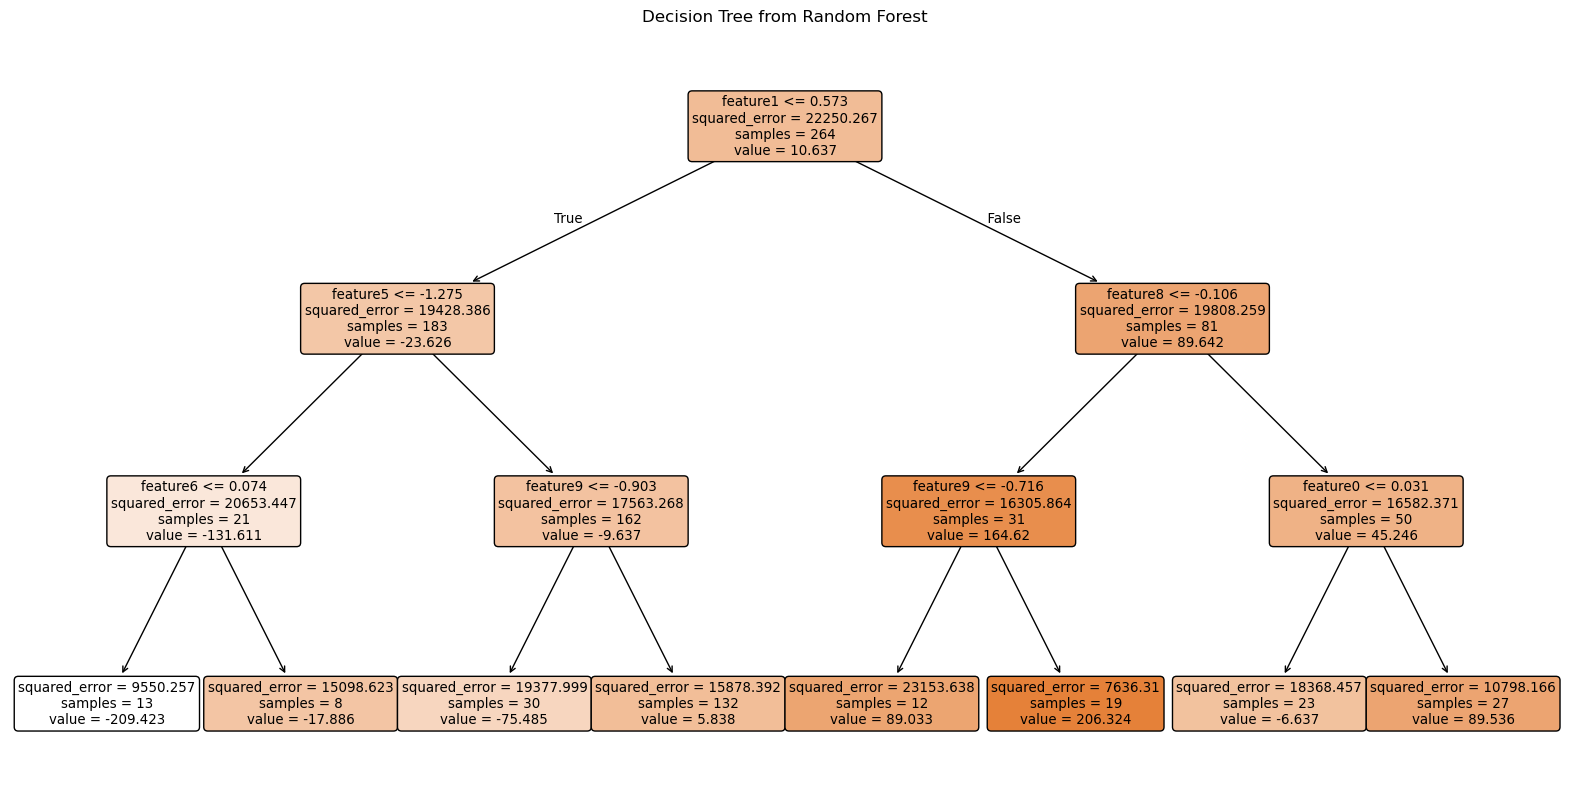

|--- x1 <= 0.57
|   |--- x5 <= -1.28
|   |   |--- x6 <= 0.07
|   |   |   |--- value: [-209.42]
|   |   |--- x6 >  0.07
|   |   |   |--- value: [-17.89]
|   |--- x5 >  -1.28
|   |   |--- x9 <= -0.90
|   |   |   |--- value: [-75.48]
|   |   |--- x9 >  -0.90
|   |   |   |--- value: [5.84]
|--- x1 >  0.57
|   |--- x8 <= -0.11
|   |   |--- x9 <= -0.72
|   |   |   |--- value: [89.03]
|   |   |--- x9 >  -0.72
|   |   |   |--- value: [206.32]
|   |--- x8 >  -0.11
|   |   |--- x0 <= 0.03
|   |   |   |--- value: [-6.64]
|   |   |--- x0 >  0.03
|   |   |   |--- value: [89.54]



In [256]:
# 1. Toy-Data
X, y = make_regression(n_samples=500,n_features=10,noise=20,random_state=42)

# 2. Train/Test-Split => predict not on data used for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Random Forest Modell
rf1 = RandomForestRegressor(
    n_estimators=100, # Number of trees (base learners)
    criterion="squared_error",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",# sqrt(p)
    bootstrap=True,
    n_jobs=-1,
    random_state=1801
)

# 4. Training
rf1.fit(X_train, y_train)

# 5. Prediction
y_pred = rf1.predict(X_test)

# 6. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # suqare root of MSE

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

tree = rf1.estimators_[0] # choose a tree in the random Forest

plt.figure(figsize=(20, 10))
plot_tree(tree,filled=True,feature_names=[f"feature{i}" for i in range(X.shape[1])],rounded=True)
plt.title("Decision Tree from Random Forest")
plt.show()

tree_rules = export_text(tree,feature_names=[f"x{i}" for i in range(X.shape[1])])
print(tree_rules)

<a class="anchor" id="overfitting"></a>
# 6. Overfitting

- RFs are less prone to overfitting than single trees
- But still possible if:
    - Trees learn mostly noise
- Increasing tree depth:
    - $\downarrow$ variance
    - usually does **not** increase overfitting

<a class="anchor" id="oob"></a>
# 7. Out-of-Bag (OOB) Error


<p align="center">
<img src="pics/17.png" width="600"/>
</p>

---

<p align="center">
<img src="pics/18.png" width="600"/>
</p>

Tree 1,3 and tree 4 were not trained on observation $(x^{(2)},y^{(2)})=((\text{brown},\text{oblong},10,\text{Imported}),\text{yes})$ with ID 2 so it is for example 
$\text{OOB}^{[1]}=\{(x^{(2)},y^{(2)})\}=\{((\text{brown},\text{oblong},10,\text{Imported}),\text{yes}) \notin \mathcal{D}^{[1]}\}$.

---

<p align="center">
<img src="pics/11.png" width="600"/>
</p>

- Uses unused data per tree for validation
- Provides:
    - Built-in estimate of generalization error (error for future unseen data denoted as $\widehat{GE}$)
    - No need for separate validation set (untouched test data to pick hyperparameters)

- Used for:
    - Model evaluation
    - Hyperparameter tuning
    - Choosing number of trees

In [257]:
np.random.seed(1002)

# Data
n = 100
X = np.random.uniform(0,100,(n,2))
y = 2*(X[:,0]**2) + X[:,1] + np.random.randn(n)*25

fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=y)

x1_grid = np.linspace(np.min(X[:,0])-1, np.max(X[:,0])+1, 50)
x2_grid = np.linspace(np.min(X[:,1])-1, np.max(X[:,1])+1, 50)
xx, yy = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack((xx.ravel(), yy.ravel()))

num_trees = 4
all_preds = []
oob_samples = [] # for out of bag samples for each tree
oob_preds = {i: [] for i in range(n)}

for i in range(num_trees):
    
    # Bootstrap
    idx = np.random.choice(n, n, replace=True)
    X_ = X[idx]
    y_ = y[idx]
    
    # OOB indices (NOT in bootstrap)
    oob_idx = np.setdiff1d(np.arange(n), idx)
    oob_samples.append(oob_idx)
    
    # Random feature
    feat_idx = np.random.choice([0,1], size=2, replace=False)
    X_sub = X_[:, feat_idx]
    X_grid_sub = X_grid[:, feat_idx]
    
    # Model
    tree = DecisionTreeRegressor(max_depth=4)
    tree.fit(X_sub, y_)
    
    preds = tree.predict(X_grid_sub)
    all_preds.append(preds)
    
    # Plot each tree
    #zz_tree = preds.reshape(xx.shape)
    #fig.add_trace(go.Surface(x=xx, y=yy, z=zz_tree,opacity=0.3,showscale=False,showlegend=True,name=f"Tree {i+1}"))

    # Estimate future error on unseen data (generalization error)
    # Predict only on OOB samples
    if len(oob_idx) > 0:
        X_oob = X[oob_idx][:, feat_idx]
        preds_oob = tree.predict(X_oob)

        for k, sample_idx in enumerate(oob_idx):
            oob_preds[sample_idx].append(preds_oob[k]) 

# Final average 
avg_preds = np.mean(all_preds, axis=0)
zz_avg = avg_preds.reshape(xx.shape)

fig.add_trace(go.Surface(x=xx, y=yy, z=zz_avg,opacity=0.7,showscale=False,showlegend=True,name="Forest (avg)"))

fig.show()

for idx,i in enumerate(oob_samples):
    print(f"OOb sample index for tree {idx}:",i)

y_oob_pred = np.full(n, np.nan)

for i in range(n):
    if len(oob_preds[i]) > 0: # check if there are no OOB samples for a tree
        y_oob_pred[i] = np.mean(oob_preds[i])

# Only use points that have OOB predictions
mask = ~np.isnan(y_oob_pred) # ~ is logiccal not (flips booleans)

mse_oob = np.mean((y[mask] - y_oob_pred[mask])**2)
rmse_oob = np.sqrt(mse_oob)

print(f"OOB MSE: {mse_oob:.2f}")
print(f"OOB RMSE: {rmse_oob:.2f}")
print("Number of samples with OOB predictions:", np.sum(mask), "out of", n)

OOb sample index for tree 0: [ 4  9 12 15 17 19 22 23 26 29 31 32 33 34 37 38 39 40 41 42 43 48 50 55
 57 59 60 64 66 67 68 75 76 82 83 84 86 89 91 98 99]
OOb sample index for tree 1: [ 1  4  5  6  9 13 14 15 17 18 19 22 23 26 27 29 30 34 36 39 40 43 45 47
 53 54 60 65 68 69 70 75 77 79 84 90 93 94 95 98]
OOb sample index for tree 2: [ 5  6  8  9 11 12 14 23 24 28 29 32 34 35 36 40 42 43 45 46 49 51 52 55
 56 60 61 64 65 66 67 72 75 78 80 81 82 86 92 96 98 99]
OOb sample index for tree 3: [ 3  4 10 11 15 20 21 22 26 27 32 39 40 41 42 43 45 48 51 54 56 60 62 63
 66 70 74 75 76 78 80 82 84 86 89 90 91 99]
OOB MSE: 199484.24
OOB RMSE: 446.64
Number of samples with OOB predictions: 87 out of 100


<a class="anchor" id="important"></a>
# 8. Feature Importance

### Helps interpret RFs (which are otherwise hard to interpret)

**Methods:**
- Permutation Importance

    - Shuffle a feature $\rightarrow$ measure drop in performance

<div style="display: flex; justify-content: center; gap: 5px;">
  <img src="pics/21.png" width="550"/>
  <img src="pics/22_.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 5px;">
  <img src="pics/23.png" width="550"/>
  <img src="pics/24.png" width="550"/>
</div>

- Impurity Importance

    - Sum improvement in splits using that feature

<div style="display: flex; justify-content: center; gap: 5px;">
  <img src="pics/20.png" width="550"/>
  <img src="pics/19.png" width="550"/>
</div>

&#10071; Both can be biased toward features with many levels (i.e.,
continuous or categoricals with many categories)

In [258]:
np.random.seed(2334)
n = 150
num_feat = 4
X,y = make_regression(n_samples=n,n_features=num_feat,bias=5,noise=40)


# baseline predictions (average over trees)
def predict_rf(X):
    preds = []
    for tree, feat_idx in models:
        preds.append(tree.predict(X[:, feat_idx]))
    return np.mean(preds, axis=0)

models = []

for i in range(num_trees):
    idx = np.random.choice(n, n, replace=True)
    X_ = X[idx]
    y_ = y[idx]

    feat_idx = np.random.choice(np.arange(num_feat), size=2, replace=False)
    X_sub = X_[:, feat_idx]

    tree_model = DecisionTreeRegressor()
    tree_model.fit(X_sub, y_)

    models.append((tree_model, feat_idx))


# baseline error
y_pred = predict_rf(X)
baseline = mean_squared_error(y, y_pred) # error with tarining data not correct in practice!

# Feature importance
# Permutation importance: permute feature 4
X_perm = X.copy()
# idx = np.random.choice(n, n, replace=False)
#X_perm[:, 3] = X_perm[idx, 3]
np.random.shuffle(X_perm[:, 3]) # shorter version (no replacement)

y_pred_perm = predict_rf(X_perm)
perm_error = mean_squared_error(y, y_pred_perm)

importance_4 = perm_error - baseline
print("Permutation importance of feature 4:", importance_4)




Permutation importance of feature 4: 1610.634449527448


<a class="anchor" id="proxi"></a>
# 9. Proximities 

- RF can measure similarity between data points
- Based on how often two points land in the same leaf

Applications:
- Visualization (clustering)
- Outlier detection (Outliers have low proximity to most observations)
- Missing value imputation (replace missing values with values from observations with close proximity)

<div style="display: flex; justify-content: center; gap: 5px;">
  <img src="pics/25.png" width="550"/>
  <img src="pics/26.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 5px;">
  <img src="pics/27.png" width="550"/>
  <img src="pics/28.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 5px;">
  <img src="pics/29.png" width="550"/>
  <img src="pics/30.png" width="550"/>
</div>

In [259]:
# 1. Data

np.random.seed(2334)

n = 150
num_feat = 4

X, y = make_regression(
    n_samples=n,
    n_features=num_feat,
    bias=5,
    noise=40
)


# 2. Train "Random Forest"
num_trees = 10
models = []

for i in range(num_trees):
    # bootstrap sample
    idx = np.random.choice(n, n, replace=True)
    X_ = X[idx]
    y_ = y[idx]

    # random feature subset
    feat_idx = np.random.choice(np.arange(num_feat), size=2, replace=False)
    X_sub = X_[:, feat_idx]

    # train tree
    tree = DecisionTreeRegressor()
    tree.fit(X_sub, y_)

    models.append((tree, feat_idx))


# 3. Prediction function
def predict_rf(X):
    preds = []
    for tree, feat_idx in models:
        preds.append(tree.predict(X[:, feat_idx]))
    return np.mean(preds, axis=0)


# 4. Permutation importance (feature 4)
# baseline error
y_pred = predict_rf(X)
baseline = mean_squared_error(y, y_pred)

# permute feature index 3 (4th feature)
X_perm = X.copy()
col = X_perm[:, 3].copy()
np.random.shuffle(col)
X_perm[:, 3] = col

# recompute error
y_pred_perm = predict_rf(X_perm)
perm_error = mean_squared_error(y, y_pred_perm)

importance_4 = perm_error - baseline

print("Permutation importance (feature 4):", importance_4)


# 5. Proximity matrix
proximity = np.zeros((n, n))

for tree, feat_idx in models:
    # leaf index for each sample
    leaves = tree.apply(X[:, feat_idx])

    # same leaf → similarity
    same_leaf = (leaves[:, None] == leaves[None, :])
    proximity += same_leaf.astype(float)

# normalize
proximity /= num_trees

print("\nProximity matrix shape:", proximity.shape)


# similarity of sample 0 to others
print("\nProximity of sample 0 to others:")
print(proximity[0][:10])  # first 10 values

# convert to distance
distance = 1 - proximity

print("\nDistance matrix example (first row):")
print(distance[0][:10])

Permutation importance (feature 4): 2914.204312796862

Proximity matrix shape: (150, 150)

Proximity of sample 0 to others:
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Distance matrix example (first row):
[0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


<a class="anchor" id="adv_disadv"></a>
# 10. Advantages & Disadvantages

### &#9989; Advantages
- Strong predictive performance
- Handles:
    - high-dimensional data
    - missing values
    - noisy features
- Little preprocessing needed
- Parallelizable
- Overall same advantages as for Trees

### &#128680; Disadvantages
- Less interpretable than single trees
- Computationally expensive (many trees)
- Memory intensive
- Poor at extrapolation (like trees)

<p align="center">
<img src="pics/5.png" width="600"/>
</p>


### &#128273; Key Takeaway

Random Forests improve decision trees by:

**Averaging many decorrelated trees $\rightarrow$ lower variance + better generalization**


<a class="anchor" id="library"></a>
# 11. Random Forest Regression library

```python
# 1. Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf1 = RandomForestRegressor(
    n_estimators=100, # number of trees
    criterion="squared_error", # "squared_error", "absolute_error"
    max_depth=None, # maximum depth of each tree
    min_samples_split=2, # min samples to split a node      
    min_samples_leaf=1, # min samples in a leaf
    max_features="sqrt", # number of features per split ("sqrt", "log2", or int)
    bootstrap=True, # use bootstrap sampling
    n_jobs=-1, # use all cores
    random_state=1801 # reproduce results
)

rf1.fit(X, y)

rf1.predict(X) # predictions
rf1.score(X, y) # R^2 score



# 2. Random Forest with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf2 = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

rf2.fit(X, y)

rf2.best_params_ # best hyperparameters
rf2.best_score_ # best CV score
rf2.best_estimator_



# 3. Feature Importance
rf1.feature_importances_  # importance of each feature



# 4. Individual Tree Visualization
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# plot one tree from the forest
plt.figure(figsize=(12, 8))
plot_tree(rf1.estimators_[0], filled=True)
plt.show()



# 5. Out-of-Bag (OOB) Score
rf_oob = RandomForestRegressor(
    n_estimators=100,
    oob_score=True,
    bootstrap=True,
    random_state=42
)

rf_oob.fit(X, y)

rf_oob.oob_score_ # OOB R^2 estimate



# 6. Randomized Search (faster tuning)
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2"]
}

rf6 = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf6.fit(X, y)

rf6.best_params_
rf6.best_score_


# 7. Train/Test Split Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf7 = RandomForestRegressor(n_estimators=100, random_state=42)
rf7.fit(X_train, y_train)

y_pred = rf7.predict(X_test)

mean_squared_error(y_test, y_pred)
rf7.score(X_test, y_test)   # R^2



# 8. Pipeline (optional preprocessing)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),  # not necessary for trees, but possible
    ("rf", RandomForestRegressor(n_estimators=100))
])

pipeline.fit(X, y)
pipeline.predict(X)



# 9. Compare with Single Decision Tree
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X, y)

tree.score(X, y)
rf1.score(X, y)   # usually more stable



# 10. Effect of number of trees
scores = []

for n in [10, 50, 100, 200]:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    scores.append(rf.score(X_test, y_test))

print(scores)



# 11. Create toy regression data for Regression
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=10,
    random_state=42
)
```

In [263]:
# 1. Create toy data (1 feature)
np.random.seed(42)

n = 100
X = np.sort(np.random.rand(n, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, size=n)

# 2. Train Random Forest

rf = RandomForestRegressor(n_estimators=10,max_depth=3,random_state=1020)
rf.fit(X, y)

# 3. Create grid for predictions

X_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

# 4. Base plot: original data
fig = px.scatter(x=X.ravel(),y=y,title="Random Forest: Data + Tree Predictions")


# 5. Add each tree prediction
for i, tree in enumerate(rf.estimators_):
    y_tree = tree.predict(X_grid)
    
    fig.add_scatter(x=X_grid.ravel(),y=y_tree,mode="lines",name=f"Tree {i}",opacity=0.4)


# 6. Add RF average prediction
y_rf = rf.predict(X_grid)

fig.add_scatter(x=X_grid.ravel(),y=y_rf,mode="lines",name="Random Forest (avg)",line=dict(width=4))

fig.show()

In [266]:
# 1. Create toy data (2 features)
np.random.seed(42)

n = 200
X = np.random.rand(n, 2) * 10
y = np.sin(X[:, 0]) + np.cos(X[:, 1]) + np.random.normal(0, 0.3, size=n)


# 2. Train Random Forest
rf = RandomForestRegressor(n_estimators=10,max_depth=4,random_state=1020)
rf.fit(X, y)


# 3. Create grid for surface
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)

xx1, xx2 = np.meshgrid(x1, x2)
X_grid = np.c_[xx1.ravel(), xx2.ravel()]


# 4. Base plot: 3D scatter
fig = px.scatter_3d(x=X[:, 0],y=X[:, 1],z=y,title="Random Forest: Data + Prediction Surfaces")


# 5. Add RF average surface
y_rf = rf.predict(X_grid).reshape(xx1.shape)

fig.add_trace(go.Surface(x=xx1,y=xx2,z=y_rf,opacity=0.6,name="RF surface",showscale=False,showlegend=True))


# 6. Add individual trees
for i, tree in enumerate(rf.estimators_):
    y_tree = tree.predict(X_grid).reshape(xx1.shape)
    fig.add_trace(go.Surface(x=xx1,y=xx2,z=y_tree,opacity=0.15,showscale=False,name=f"Tree {i}",showlegend=True))


fig.show()